# 5. Evaluation

**Project:** Predicting colorectal cancer screening non-compliance to guide targeted outreach
**Part of:** the modelling stage. Notebooks `4a`-`4d` each fit one model family (Logistic
Regression, Random Forest, Gradient Boosting, Feedforward Neural Network) across the M1/M2/M3
predictor domains and register every fitted pipeline into a shared manifest
(`data/processed/modelling/model_registry_manifest.csv`).

**This notebook does not fit anything.** It loads every model already registered by `4a`-`4d`
from that shared manifest and compares them -- run `4a`-`4d` first (in any order; each merges
into the shared manifest independently, so re-running one doesn't erase the others' rows).

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sys.path.insert(0, str(Path.cwd()))  # joblib needs pipeline_components importable to unpickle OrdinalRankWithMissingFlag
from pipeline_components import make_model_registry

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROCESSED_DIR / "modelling"
MODELS_DIR = MODEL_DIR / "models"
MANIFEST_PATH = MODEL_DIR / "model_registry_manifest.csv"
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"{MANIFEST_PATH} not found. Run notebooks 4a-4d first.")

_, register_model, load_registry = make_model_registry(MODELS_DIR, MANIFEST_PATH)
MODEL_REGISTRY = load_registry()
print(f"Loaded {len(MODEL_REGISTRY)} models from the shared manifest: {MANIFEST_PATH}")
print(sorted(MODEL_REGISTRY.keys()))

Loaded 15 models from the shared manifest: ../data/processed/modelling/model_registry_manifest.csv
['ffnn_M1', 'ffnn_M2', 'ffnn_M3', 'ffnn_M3_tuned', 'gb_M1', 'gb_M2', 'gb_M3', 'gb_M3_tuned', 'logreg_M1', 'logreg_M2', 'logreg_M3', 'rf_M1', 'rf_M2', 'rf_M3', 'rf_M3_tuned']


## Model comparison

Every model registered by `4a`-`4d` -- three domains (M1/M2/M3) x four families (logistic
regression, random forest, gradient boosting, feedforward neural network), plus the tuned random
forest, gradient boosting, and neural network variants -- loaded from the shared manifest and
brought together into one table.

In [2]:
comparison_table = (
    pd.DataFrame([
        {"name": name, "model_type": entry["model_type"], "n_features": entry["n_features"], **entry["metrics"]}
        for name, entry in MODEL_REGISTRY.items()
    ])
    .sort_values("AUROC", ascending=False)
    .reset_index(drop=True)
)
comparison_table.to_csv(MODEL_DIR / "model_comparison_table.csv", index=False)
comparison_table.round(4)

,name,model_type,n_features,AUROC,AUPRC,Precision,Sensitivity,F1,Accuracy
0,gb_M3_tuned,"Gradient Boosting (class-weighted, RandomizedS...",17,0.7662,0.5974,0.4910,0.6385,0.5551,0.7291
1,gb_M3,"Gradient Boosting (class-weighted, HistGradien...",17,0.7659,0.5970,0.4888,0.6364,0.5529,0.7275
2,ffnn_M3_tuned,"Feedforward Neural Network (class-weighted, Ra...",17,0.7638,0.5910,0.4706,0.6661,0.5516,0.7132
3,gb_M2,"Gradient Boosting (class-weighted, HistGradien...",12,0.7636,0.5940,0.4878,0.6378,0.5528,0.7268
4,ffnn_M3,"Feedforward Neural Network (class-weighted, ML...",17,0.7623,0.5893,0.4941,0.6231,0.5512,0.7313
5,rf_M3_tuned,"Random Forest (class-weighted, RandomizedSearc...",17,0.7620,0.5905,0.4914,0.6292,0.5518,0.7294
6,rf_M3,"Random Forest (class-weighted, min_samples_lea...",17,0.7613,0.5910,0.4986,0.6180,0.5519,0.7343
7,ffnn_M2,"Feedforward Neural Network (class-weighted, ML...",12,0.7609,0.5897,0.4935,0.6237,0.5510,0.7309
8,rf_M2,"Random Forest (class-weighted, min_samples_lea...",12,0.7601,0.5889,0.4919,0.6283,0.5518,0.7298
9,logreg_M3,Logistic Regression (class-weighted),17,0.7547,0.5835,0.4729,0.6451,0.5458,0.7157


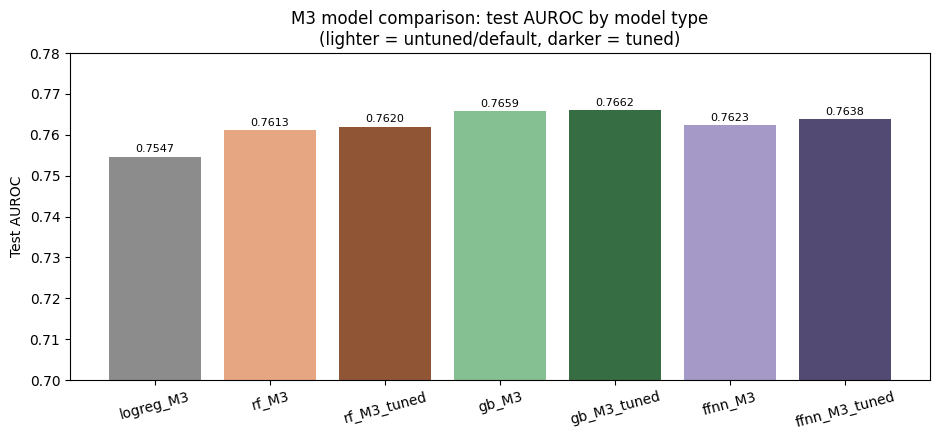

In [3]:
# Colour-coded by model family, with the untuned/tuned pair for each family sharing a hue
# (lighter = untuned/default, darker = tuned) so the effect of tuning is visually obvious within
# a family, and different families are still easy to tell apart. Logistic regression has no tuned
# counterpart, so it keeps a neutral grey.
FAMILY_COLORS = {
    "logreg_M3": "#8C8C8C",       # grey -- baseline, no tuned variant
    "rf_M3": "#E6A682",           # orange, light  = untuned
    "rf_M3_tuned": "#8F5535",     # orange, dark   = tuned
    "gb_M3": "#84C092",           # green, light   = untuned
    "gb_M3_tuned": "#376D43",     # green, dark    = tuned
    "ffnn_M3": "#A499C7",         # purple, light  = untuned
    "ffnn_M3_tuned": "#534A73",   # purple, dark   = tuned
}
order = list(FAMILY_COLORS.keys())

m3_models = comparison_table[comparison_table["name"].isin(order)].copy()
m3_models["name"] = pd.Categorical(m3_models["name"], categories=order, ordered=True)
m3_models = m3_models.sort_values("name")

fig, ax = plt.subplots(figsize=(9.5, 4.5))
colors_bar = [FAMILY_COLORS[n] for n in m3_models["name"]]
bars = ax.bar(m3_models["name"], m3_models["AUROC"], color=colors_bar)
ax.set_ylim(0.7, 0.78)
ax.set_ylabel("Test AUROC")
ax.set_title("M3 model comparison: test AUROC by model type\n(lighter = untuned/default, darker = tuned)")
ax.tick_params(axis="x", labelrotation=15)
for bar, val in zip(bars, m3_models["AUROC"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001, f"{val:.4f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig17_model_comparison_auroc.png", dpi=150)
plt.show()

**Reading the comparison:**

Two patterns hold consistently across all four model families: adding predictor domains always
helps (M1 -> M2 -> M3 improves AUROC every time, though the M2 -> M3 step is small -- most of the
lift comes from adding access-to-care variables in M2, with the M3 health variables adding little
on top), and the non-linear models (random forest, gradient boosting, feedforward network) all
comfortably beat logistic regression, with gradient boosting narrowly ahead of the other two.

**Gradient boosting (M3, tuned) remains the best-performing model overall** at test AUROC 0.7662,
just ahead of the untuned gradient boosting default (0.7659). The feedforward network's tuned
variant (0.7638) lands between the two gradient boosting models and the two random forest models
(0.7613-0.7620) -- a genuinely competitive result for a fourth model added beyond the original
proposal, and further evidence that this dataset's signal is dominated by a handful of strong,
somewhat non-linear predictors (age and recent-checkup history) that any reasonably-capable
non-linear model can extract, rather than by a lot of easily-missed complexity.

**Hyperparameter search moved the needle by different amounts for each model, visible directly in
the chart above as the gap between each family's light (untuned) and dark (tuned) bar.** Random
forest was essentially a tie (0.7613 -> 0.7620, barely visible); gradient boosting also barely
moved (0.7659 -> 0.7662); the feedforward network showed the largest -- still modest -- gain
(0.7623 -> 0.7638), and unlike the other two, its tuning came with a visible precision/recall
trade-off (sensitivity up from 0.623 to 0.666, precision down from 0.494 to 0.471) rather than a
clean win across every metric. Switching model *family* mattered more for AUROC than tuning
*within* a family for every model tried so far, which is a reasonable prior for where to spend
further effort -- calibration, threshold selection, and subgroup performance are likely to matter
more for the final deliverable than a larger search.

**Accuracy leaders vs. interpretability model of record are different models, and that's expected,
not a problem.** All three non-linear models outperform logistic regression on ranking metrics,
but none of them has coefficients -- their "Analysis of factors" sections (in `4b`, `4c`, `4d`)
all rely on permutation importance, which explains *how much* a predictor matters to the model's
predictions but not the *direction and per-category size* of its association with non-compliance
the way an odds ratio does. Per the project proposal, logistic regression remains the
interpretability model of record (the odds-ratio table and forest plot in `4a`); gradient boosting
(tuned) is the candidate for the leading model if the deliverable prioritises predictive
performance for targeting outreach. All three non-linear models' permutation-importance rankings
agree with each other far more than they agree with the logistic regression odds ratios on
relative magnitude -- particularly `age_group`, whose non-linear relationship with non-compliance
(see the EDA notebook) a non-linear model can exploit directly in a way one linear coefficient
understates. That's a real, worth-reporting distinction between what "important" means under each
model, not a contradiction to be resolved.

**Still deferred**, unaffected by which model leads: real geographic-fold evaluation and
subgroup/equity performance reporting on whichever model is carried forward. Calibration is
addressed directly below.

## Calibration

`predict_proba` output isn't automatically a trustworthy probability. Every model in `4a`-`4d`
was fit with `sample_weight="balanced"` to help ranking and sensitivity under the 26.5%
non-compliance rate -- a deliberate, good choice for a model that needs to rank people by risk --
but a known side effect is that it pushes raw predicted probabilities away from the true base
rate, since the model is effectively fit as if the two classes were closer to 50/50. A model can
still rank people correctly (AUROC/AUPRC unaffected) while its stated "73% risk" is not a real
73%.

This section takes the leading model (`gb_M3_tuned`, the best test AUROC in the comparison above)
exactly as already fit -- no retraining -- and fits a small isotonic-regression correction curve
on top of its output, using **only the calibration split** (`X_cal`/`y_cal`), which neither the
model itself nor any hyperparameter search has ever seen. This is what the train/calibration/test
split was set aside for. `sklearn`'s `CalibratedClassifierCV(FrozenEstimator(...))` does exactly
this: the wrapped estimator's parameters are frozen (not refit), and only the calibration mapping
is learned from the data passed to `.fit()`.

In [4]:
from pipeline_components import M3_FEATURES

ANALYTIC_PATH = PROCESSED_DIR / "crc_analytic_dataset.csv"
SPLIT_PATH = MODEL_DIR / "train_calibration_test_split.csv"

df = pd.read_csv(
    ANALYTIC_PATH,
    dtype={"respondent_id": "string", "state_fips": "string"},
    low_memory=False,
)
split_assignment = pd.read_csv(SPLIT_PATH, dtype={"respondent_id": "string"})
df = df.merge(split_assignment, on="respondent_id", validate="one_to_one")

X_cal = df.loc[df["split"] == "calibration", M3_FEATURES]
y_cal = df.loc[df["split"] == "calibration", "crc_noncompliant"]
X_test = df.loc[df["split"] == "test", M3_FEATURES]
y_test = df.loc[df["split"] == "test", "crc_noncompliant"]

print(f"Calibration set: n={len(X_cal):,}   non-compliance rate={y_cal.mean():.4f}")
print(f"Test set:        n={len(X_test):,}   non-compliance rate={y_test.mean():.4f}")

Calibration set: n=45,529   non-compliance rate=0.2648
Test set:        n=45,530   non-compliance rate=0.2648


In [5]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

LEADING_MODEL = "gb_M3_tuned"
leading_pipeline = MODEL_REGISTRY[LEADING_MODEL]["pipeline"]

proba_raw_test = leading_pipeline.predict_proba(X_test[M3_FEATURES])[:, 1]

calibrator = CalibratedClassifierCV(FrozenEstimator(leading_pipeline), method="isotonic")
calibrator.fit(X_cal[M3_FEATURES], y_cal)  # only the calibration split -- the base pipeline is frozen, not refit

proba_cal_test = calibrator.predict_proba(X_test[M3_FEATURES])[:, 1]

brier_raw = brier_score_loss(y_test, proba_raw_test)
brier_cal = brier_score_loss(y_test, proba_cal_test)

print(f"Mean predicted risk, raw {LEADING_MODEL}:  {proba_raw_test.mean():.4f}")
print(f"Mean predicted risk, calibrated:           {proba_cal_test.mean():.4f}")
print(f"Observed non-compliance rate (test):       {y_test.mean():.4f}")
print()
print(f"Brier score, raw:         {brier_raw:.4f}")
print(f"Brier score, calibrated:  {brier_cal:.4f}")

Mean predicted risk, raw gb_M3_tuned:  0.4477
Mean predicted risk, calibrated:           0.2643
Observed non-compliance rate (test):       0.2648

Brier score, raw:         0.1898
Brier score, calibrated:  0.1538


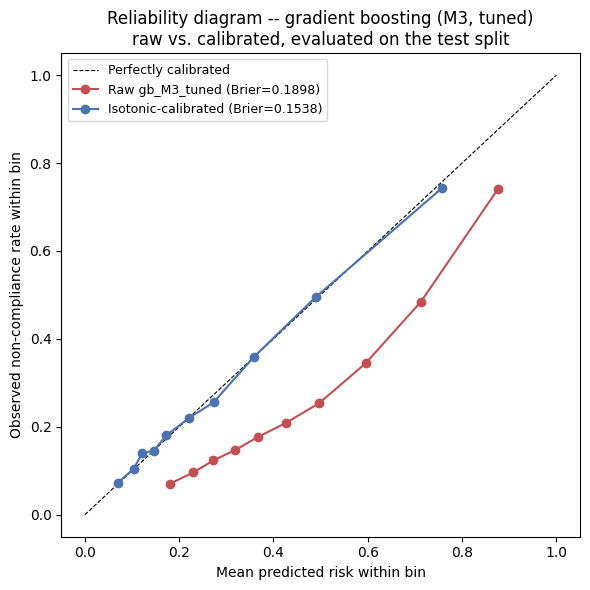

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, proba_raw_test, n_bins=10, strategy="quantile")
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, proba_cal_test, n_bins=10, strategy="quantile")

ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8, label="Perfectly calibrated")
ax.plot(mean_pred_raw, frac_pos_raw, marker="o", color="#C44E52",
        label=f"Raw {LEADING_MODEL} (Brier={brier_raw:.4f})")
ax.plot(mean_pred_cal, frac_pos_cal, marker="o", color="#4C72B0",
        label=f"Isotonic-calibrated (Brier={brier_cal:.4f})")
ax.set_xlabel("Mean predicted risk within bin")
ax.set_ylabel("Observed non-compliance rate within bin")
ax.set_title("Reliability diagram -- gradient boosting (M3, tuned)\nraw vs. calibrated, evaluated on the test split")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig20_calibration_reliability_diagram.png", dpi=150)
plt.show()

**Reading this:** the raw model's mean predicted risk sits well above the observed 26.5%
non-compliance rate -- the `sample_weight="balanced"` effect described above, playing out exactly
as expected. The reliability curve confirms it's systematic, not just a mean shift: the raw
model's points sit above the diagonal across most of the risk range, meaning "60% predicted risk"
corresponds to a lower true rate than 60% almost everywhere. The isotonic-calibrated curve tracks
the diagonal much more closely, and the Brier score (lower is better) improves accordingly.

**This does not change the model's ranking ability** -- isotonic regression is a monotonic
transform, so a person predicted higher-risk than another stays higher-risk after calibration,
and AUROC/AUPRC are unaffected (confirmed in the table below). What changes is whether a specific
number like "73%" can be taken at face value, and whether a fixed threshold like 0.5 means the
same thing before and after. That second point matters concretely: the classification metrics
below recompute Precision/Sensitivity/F1/Accuracy at the same 0.5 cutoff on the calibrated
probabilities, and they move -- not because the model changed, but because "0.5" now sits at a
different point in the corrected probability distribution than it did in the inflated raw one.

In [7]:
from pipeline_components import compute_classification_metrics

raw_metrics = compute_classification_metrics(y_test, proba_raw_test)
cal_metrics = compute_classification_metrics(y_test, proba_cal_test)

calibration_comparison = pd.DataFrame([
    {"Model": f"{LEADING_MODEL} (raw)", **raw_metrics},
    {"Model": f"{LEADING_MODEL} (isotonic-calibrated)", **cal_metrics},
])
calibration_comparison.round(4)

,Model,AUROC,AUPRC,Precision,Sensitivity,F1,Accuracy
0,gb_M3_tuned (raw),0.7662,0.5974,0.4910,0.6385,0.5551,0.7291
1,gb_M3_tuned (isotonic-calibrated),0.7659,0.5892,0.6927,0.3461,0.4616,0.7862


In [8]:
register_model(
    name=f"{LEADING_MODEL}_calibrated",
    pipeline=calibrator,
    metrics=cal_metrics,
    features=M3_FEATURES,
    model_type="Gradient Boosting (isotonic-calibrated via CalibratedClassifierCV on held-out calibration split)",
    notes=(f"Wraps the already-fitted {LEADING_MODEL} pipeline via FrozenEstimator -- base model not "
           f"retrained, only an isotonic correction fit on the calibration split. "
           f"Brier score {brier_raw:.4f} (raw) -> {brier_cal:.4f} (calibrated)."),
)
print(f"Registered '{LEADING_MODEL}_calibrated' in the shared manifest.")

Registered 'gb_M3_tuned_calibrated' in the shared manifest.


**Registered as `gb_M3_tuned_calibrated`** alongside the other 15 models in the shared manifest,
so it's available without refitting anything if a later step -- individual risk scores, a
risk-decile table, or subgroup-level predicted-vs-observed rates -- needs probabilities that are
actually trustworthy as probabilities, not just useful for ranking. The uncalibrated `gb_M3_tuned`
remains the correct model to cite for pure ranking metrics (AUROC/AUPRC in the comparison table
above); the calibrated version is the one to use anywhere a predicted probability is reported or
acted on directly.